# Exploración inicial
### Proyecto: Predicción de la gravedad de accidentes de tránsito en Costa Rica

### Integrantes: Sebastián Calvo Solano, Carlos Cambronero Zúñiga

La idea de este notebook es mostrar y explicar la parte de la visualización e interpretación de resultados.

Etapas que se recorren aquí:
1. Carga de los datos ya procesados (`GestorDatos`)
2. Análisis exploratorio de datos (`ProcesadorEDA`)
3. Visualización estática (`Visualizador`) y mapa interactivo (`MapaAccidentes`)
4. Relación con el clima
5. Primer vistazo al modelado predictivo (`PreparadorModelo`, `EntrenadorModelos`)


## 1. Configuración inicial

Se agrega `src/` al path para poder importar las clases del proyecto, igual que hace `main.py`.

In [1]:
import os # Es la librería que permite interactuar con el sistema operativo
import sys # Control de python con el sistema operativo
# Ambos en conjunto permiten que el programa pueda tanto desplazarse como manipular elementos en el equipo

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline # Fuerza a los gráficos a mostrarse debajo del código
pd.set_option("display.max_columns", None) # Elimina límite máximo para mostrar

# notebooks/ vive junto a src/, en la raíz del proyecto
CARPETA_PROYECTO = os.path.abspath(os.path.join(os.getcwd(), ".."))
CARPETA_SRC = os.path.join(CARPETA_PROYECTO, "src")

if CARPETA_SRC not in sys.path:
    sys.path.insert(0, CARPETA_SRC)

print("Carpeta del proyecto:", CARPETA_PROYECTO)


Carpeta del proyecto: C:\PrograII\Proyecto_III


In [2]:
from datos.GestorDatos import GestorDatos
from eda.ProcesadorEDA import ProcesadorEDA
from visualizacion.Visualizador import Visualizador
from visualizacion.MapaAccidentes import MapaAccidentes
from modelos.PreparadorModelo import PreparadorModelo
from modelos.EntrenadorModelos import EntrenadorModelos


## 2. Carga de los datos procesados

Se reutiliza `GestorDatos.cargar_csv_procesado()`, el mismo método que usa `main.py` para volver a leer el CSV limpio (no se vuelve a limpiar nada aquí).

In [3]:
gestor_datos = GestorDatos()

accidentes = gestor_datos.cargar_csv_procesado("accidentes_victimas_limpio.csv")

ruta_clima = os.path.join(
    gestor_datos.ruta_processed,
    "clima_mensual_2018_2024.csv"
)

clima = pd.read_csv(ruta_clima, sep=";", encoding="utf-8-sig")

print("Accidentes:", accidentes.shape)
print("Clima mensual:", clima.shape)


Accidentes: (104821, 24)
Clima mensual: (588, 8)


In [5]:
accidentes.head(n = 10)

,clase_accidente,tipo_accidente,anio,hora,hora_recodificada,provincia,canton,distrito,ruta,kilometro,zona,calzada_vertical,calzada_horizontal,tipo_calzada,tipo_circulacion,estado_tiempo,estado_calzada,region_mideplan,tipo_ruta,dia_numero,dia,mes_numero,mes,gravedad
0,Solo heridos leves,Salió de la vía,2024,20:00-20:59,18:00-23:59,Limón,Pococí,Guápiles,32,43,Rural,Pendiente,Curva,Asfalto,Lateral igual sentido,Lluvia,Resbaladiza,Huetar caribe,Nacional,7,Sábado,4,Abril,0
1,Solo heridos leves,Colisión con motocicleta,2024,06:00-06:59,06:00-11:59,Heredia,San Isidro,San José,32,12,Urbana,Plano,Recta,Asfalto,Angulo recto,Buen tiempo,Buena,Central,Nacional,3,Martes,5,Mayo,0
2,Con muertos o graves,Vuelco,2024,15:00-15:59,12:00-17:59,San José,Vázquez de Coronado,Dulce Nombre de Jesús,32,21,Rural,Pendiente,Curva,Asfalto,Lateral igual sentido,Buen tiempo,Buena,Central,Nacional,6,Viernes,5,Mayo,1
3,Solo heridos leves,Colisión entre vehículos,2024,08:00-08:59,06:00-11:59,Heredia,Santo Domingo,San Miguel,32,7,Urbana,Plano,Recta,Asfalto,Por detrás,Buen tiempo,Buena,Central,Nacional,3,Martes,7,Julio,0
4,Solo heridos leves,Colisión con motocicleta,2024,07:00-07:59,06:00-11:59,Heredia,Santo Domingo,San Miguel,32,5,Urbana,Plano,Recta,Asfalto,Lateral igual sentido,Buen tiempo,Buena,Central,Nacional,3,Martes,8,Agosto,0
5,Solo heridos leves,Colisión con motocicleta,2024,16:00-16:59,12:00-17:59,San José,Goicoechea,Calle Blancos,32,0,Urbana,Plano,Recta,Asfalto,Por detrás,Buen tiempo,Buena,Central,Nacional,3,Martes,9,Setiembre,0
6,Solo heridos leves,Salió de la vía,2024,12:00-12:59,12:00-17:59,San José,Moravia,San Jerónimo,32,17,Rural,Pendiente,Recta,Asfalto,Lateral en sentido contrario,Buen tiempo,Buena,Central,Nacional,4,Miércoles,10,Octubre,0
7,Solo heridos leves,Colisión entre vehículos,2024,14:00-14:59,12:00-17:59,San José,Vázquez de Coronado,Dulce Nombre de Jesús,32,22,Rural,Pendiente,Curva,Asfalto,Lateral en sentido contrario,Buen tiempo,Buena,Central,Nacional,7,Sábado,10,Octubre,0
8,Solo heridos leves,Colisión con objeto fijo,2024,10:00-10:59,06:00-11:59,Heredia,Santo Domingo,Santa Rosa,5,4,Urbana,Pendiente,Recta,Asfalto,De frente,Buen tiempo,Buena,Central,Nacional,5,Jueves,1,Enero,0
9,Solo heridos leves,Atropello a persona,2024,11:00-11:59,06:00-11:59,Heredia,Heredia,Mercedes,Cantonal,Cantonal,Urbana,Plano,Recta,Asfalto,De frente,Buen tiempo,Huecos,Central,Cantonal,2,Lunes,1,Enero,0


## 3. Análisis exploratorio de datos

Se crea un único `ProcesadorEDA` a partir del cual salen todas las tablas de esta sección.

In [6]:
eda = ProcesadorEDA(accidentes)

eda.resumen_general()


{'cantidad_filas': 104821,
 'cantidad_columnas': 24,
 'cantidad_duplicados': np.int64(0),
 'total_valores_vacios': np.int64(0),
 'anio_inicial': 2018,
 'anio_final': 2024,
 'cantidad_provincias': 7}

### 3.1 Tipos de datos y valores vacíos

In [7]:
display(eda.obtener_tipos_datos())
display(eda.analizar_valores_vacios())


,columna,tipo_dato
0,clase_accidente,str
1,tipo_accidente,str
2,anio,int64
3,hora,str
4,hora_recodificada,str
5,provincia,str
6,canton,str
7,distrito,str
8,ruta,str
9,kilometro,str


,columna,cantidad_vacios,porcentaje_vacios
0,clase_accidente,0,0.0
1,tipo_accidente,0,0.0
2,anio,0,0.0
3,hora,0,0.0
4,hora_recodificada,0,0.0
5,provincia,0,0.0
6,canton,0,0.0
7,distrito,0,0.0
8,ruta,0,0.0
9,kilometro,0,0.0


Observamos que hay un total de 23 variables (columnas) y ninguna posee valores nulos o elementos vacíos

### 3.2 Distribución de la gravedad

Variable objetivo del modelo: `0 = Solo heridos leves`, `1 = Con muertos o graves`.

In [10]:
eda.distribucion_gravedad()

,gravedad,clase_accidente,cantidad_accidentes,porcentaje
0,0,Solo heridos leves,89541,85.42
1,1,Con muertos o graves,15280,14.58


Observamos como casi un 15% de los datos son accidentes graves y/o muertos

### 3.3 Análisis temporal

In [9]:
tabla_anio = eda.accidentes_por_anio()
tabla_mes = eda.accidentes_por_mes()
tabla_dia = eda.accidentes_por_dia()
tabla_hora = eda.accidentes_por_hora()

display(tabla_anio)
display(tabla_mes)


,anio,cantidad_accidentes
0,2018,14737
1,2019,14850
2,2020,11784
3,2021,14136
4,2022,15621
5,2023,16661
6,2024,17032


,mes_numero,mes,cantidad_accidentes
0,1,Enero,8628
1,2,Febrero,8760
2,3,Marzo,9502
3,4,Abril,8117
4,5,Mayo,8480
5,6,Junio,8141
6,7,Julio,8480
7,8,Agosto,8801
8,9,Setiembre,8525
9,10,Octubre,8700


Resumen de las estadísticas de accidentes por año y por mes, observando como Diciembre es el mes con mas accidentes y 2024 el año con mas accidentes.

### 3.4 Análisis geográfico y de gravedad

In [8]:
tabla_provincia = eda.accidentes_por_provincia()
tabla_gravedad_provincia = eda.gravedad_por_provincia()
tabla_tipo = eda.accidentes_por_tipo()

display(tabla_provincia)
display(tabla_gravedad_provincia)


,provincia,cantidad_accidentes
0,San José,36780
1,Alajuela,20802
2,Puntarenas,11548
3,Heredia,10221
4,Cartago,9357
5,Guanacaste,8125
6,Limón,7988


,provincia,total_accidentes,accidentes_graves,accidentes_leves,porcentaje_graves
0,Guanacaste,8125,3040,5085,37.42
1,Limón,7988,2380,5608,29.79
2,Puntarenas,11548,2389,9159,20.69
3,Alajuela,20802,2587,18215,12.44
4,Cartago,9357,896,8461,9.58
5,Heredia,10221,889,9332,8.70
6,San José,36780,3099,33681,8.43


Este nos dice los accidentes por provincia, siendo San José la que mas tiene pero siendo Guanacaste la que mas accidentes graves tiene en porcentaje.

### 3.5 Gravedad según otras categorías

`ProcesadorEDA` trae un método `gravedad_por_*` para cada variable categórica relevante.

In [11]:
display(eda.gravedad_por_tipo_accidente())
display(eda.gravedad_por_zona())
display(eda.gravedad_por_tipo_ruta())
display(eda.gravedad_por_estado_tiempo())
display(eda.gravedad_por_estado_calzada())


,tipo_accidente,total_accidentes,accidentes_graves,accidentes_leves,porcentaje_graves
0,Colisión con objeto fijo,3226,746,2480,23.12
1,Desconocido,217,47,170,21.66
2,Atropello a persona,11680,2254,9426,19.30
3,Salió de la vía,7547,1292,6255,17.12
4,Objeto sobre vehículo,136,23,113,16.91
5,Atropello animal,1018,159,859,15.62
6,Colisión con motocicleta,42645,6517,36128,15.28
7,Colisión con bicicleta,8229,1209,7020,14.69
8,Vuelco,3744,476,3268,12.71
9,Otros,1694,200,1494,11.81


,zona,total_accidentes,accidentes_graves,accidentes_leves,porcentaje_graves
0,Rural,25058,6160,18898,24.58
1,Urbana,77953,8927,69026,11.45
2,Desconocida,1810,193,1617,10.66


,tipo_ruta,total_accidentes,accidentes_graves,accidentes_leves,porcentaje_graves
0,Nacional,68157,10993,57164,16.13
1,Nacional sin coordenada,306,41,265,13.40
2,Cantonal,34854,4094,30760,11.75
3,Ignorada,1504,152,1352,10.11


,estado_tiempo,total_accidentes,accidentes_graves,accidentes_leves,porcentaje_graves
0,Neblina,479,106,373,22.13
1,Buen tiempo,88266,13047,75219,14.78
2,Lluvia con neblina,150,22,128,14.67
3,Lluvia,11359,1581,9778,13.92
4,Desconocido,4567,524,4043,11.47


,estado_calzada,total_accidentes,accidentes_graves,accidentes_leves,porcentaje_graves
0,Hundimientos,518,98,420,18.92
1,Huecos,2767,505,2262,18.25
2,Construcción o reparación,1164,207,957,17.78
3,Otros,1022,175,847,17.12
4,Buena,90751,13262,77489,14.61
5,Resbaladiza,1191,150,1041,12.59
6,Desconocido,7408,883,6525,11.92


### 3.6 Cruce día de la semana × franja horaria

In [12]:
tabla_dia_hora = eda.tabla_dia_hora()
tabla_dia_hora

,dia_numero,dia,00:00-05:59,06:00-11:59,12:00-17:59,18:00-23:59
0,1,Domingo,2415,2930,4631,4648
1,2,Lunes,1216,4952,5169,4014
2,3,Martes,764,4714,4933,4006
3,4,Miércoles,825,4437,4859,4125
4,5,Jueves,844,4482,4811,4116
5,6,Viernes,1089,4447,5427,5176
6,7,Sábado,1732,3597,5323,5139


Observamos que los días con mas accidentes son los viernes y sábados en el lapso entre 12:00 17:59 ambos con mas de 5300 registros.

## 4. Visualización

`Visualizador` guarda cada gráfico como PNG en `graficos/` y además retorna la ruta. Aquí se muestran directamente en el notebook con `plt.show()`.

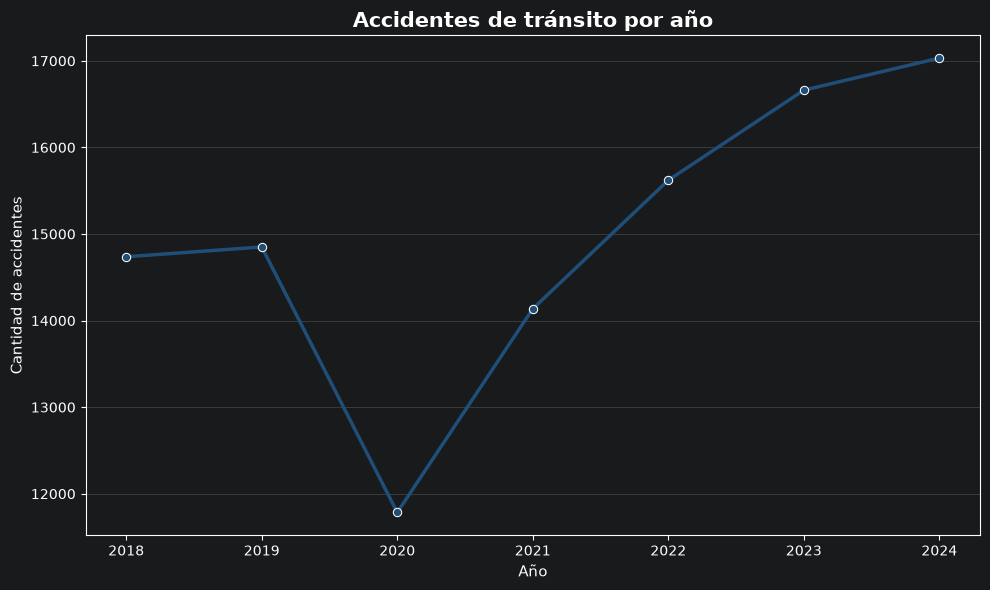

In [13]:
visualizador = Visualizador()

visualizador.grafico_accidentes_por_anio(tabla_anio)
plt.show()


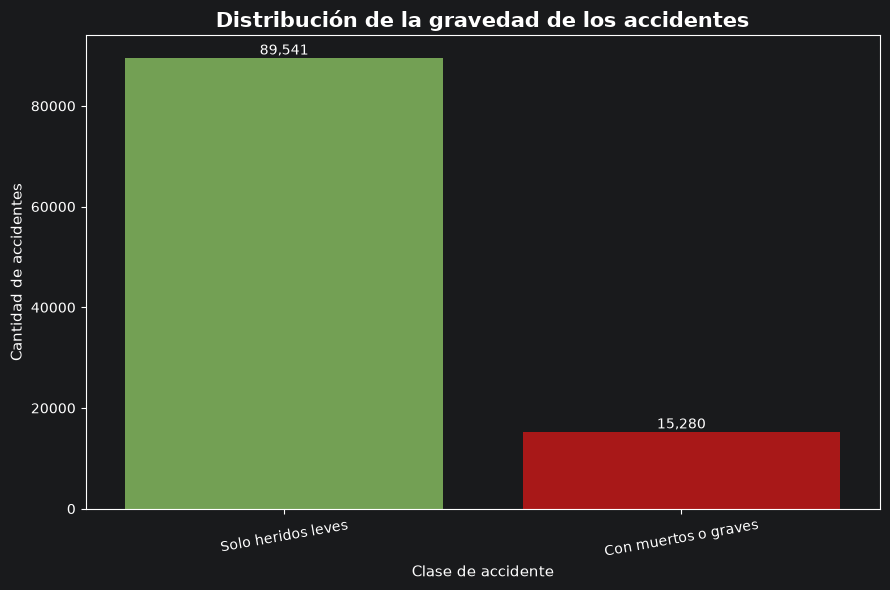

In [14]:
visualizador.grafico_distribucion_gravedad(eda.distribucion_gravedad())
plt.show()


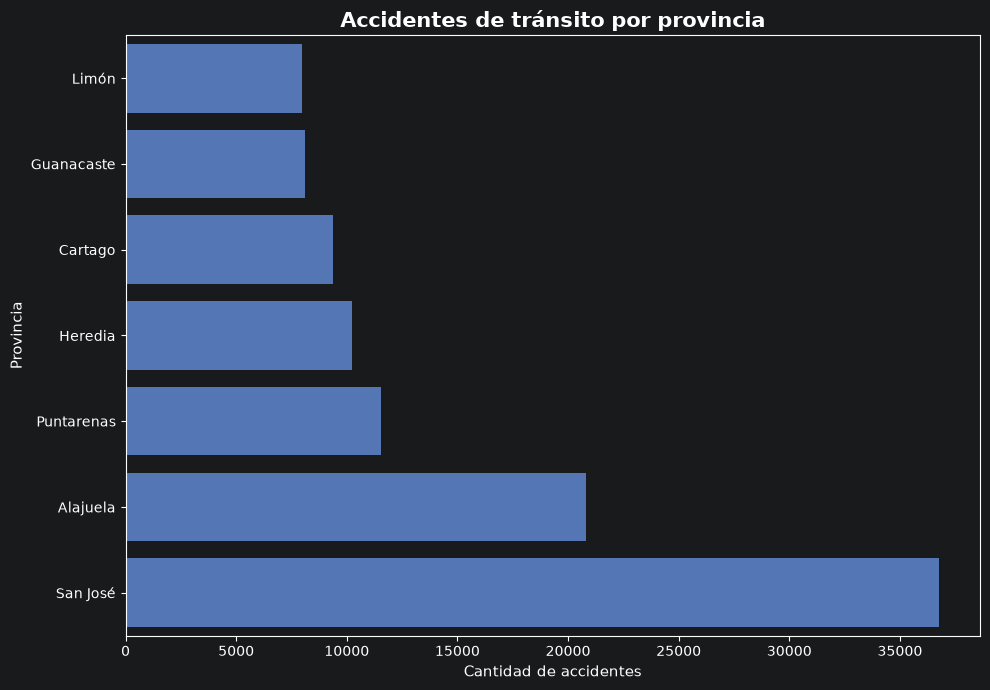

In [15]:
visualizador.grafico_accidentes_por_provincia(tabla_provincia)
plt.show()


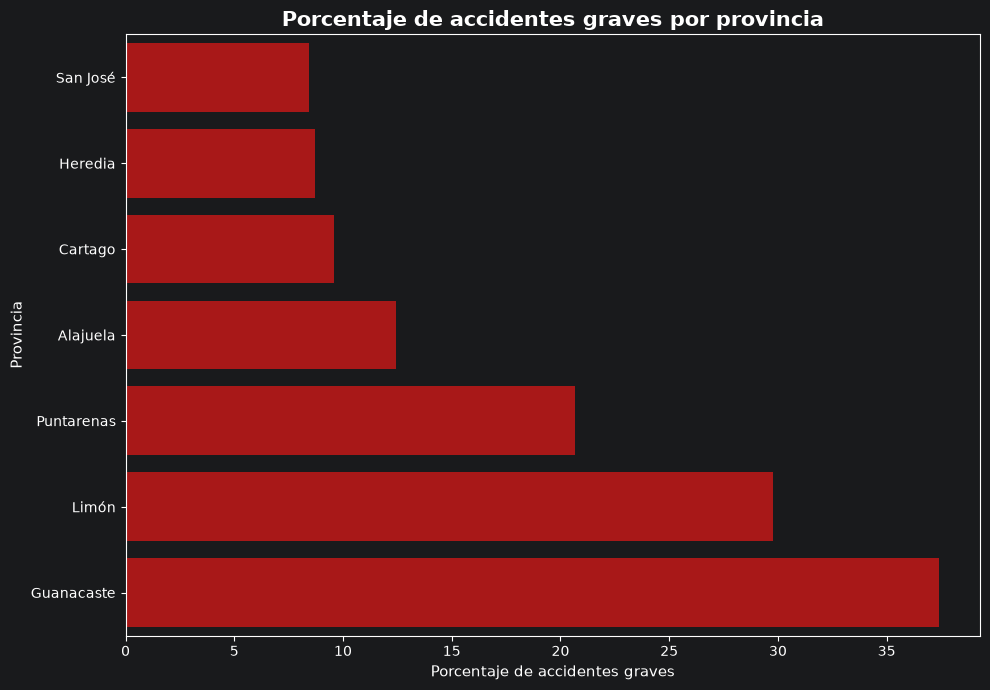

In [16]:
visualizador.grafico_gravedad_por_provincia(tabla_gravedad_provincia)
plt.show()


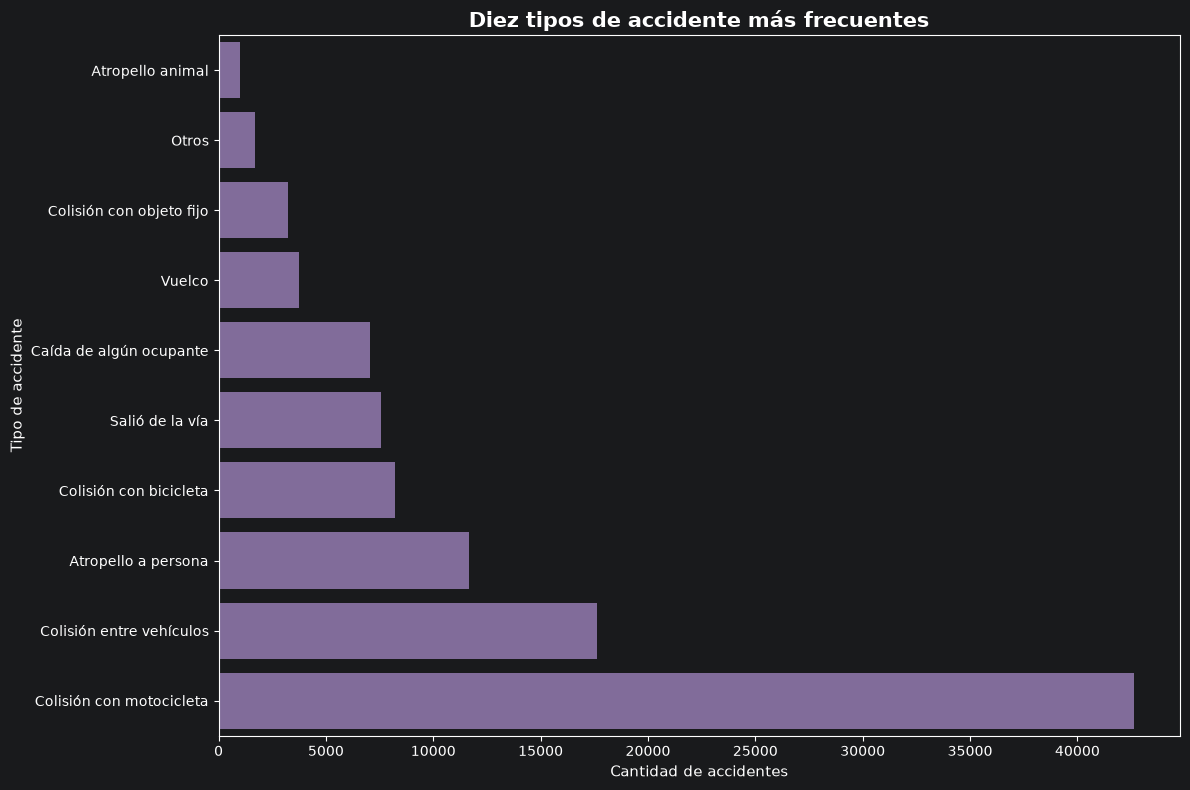

In [17]:
visualizador.grafico_tipos_accidente(tabla_tipo)
plt.show()


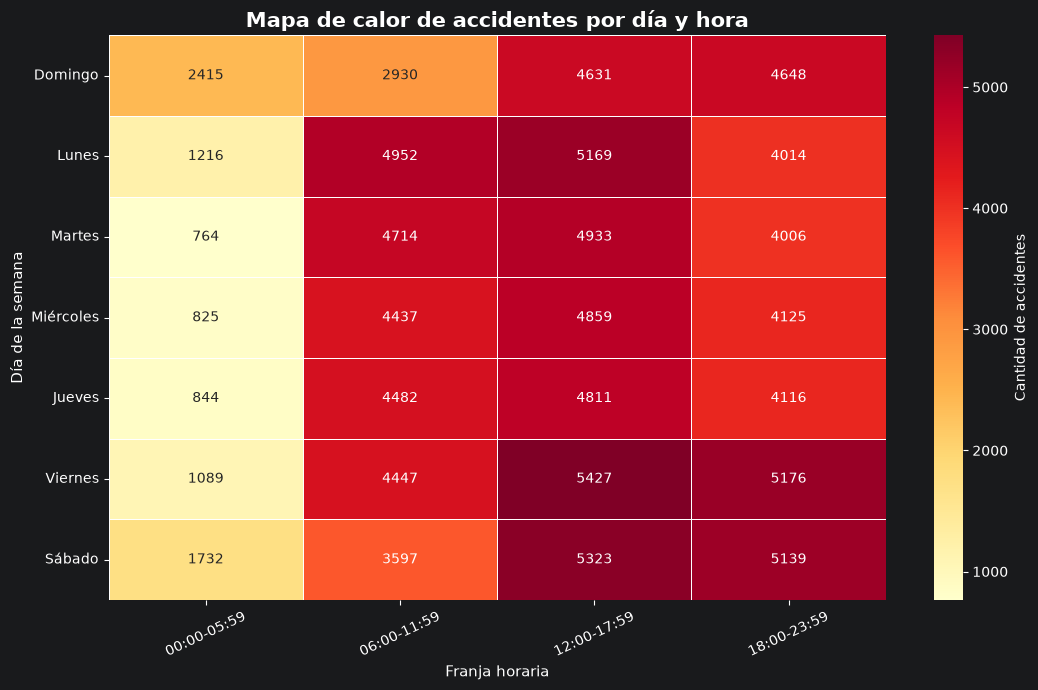

In [18]:
visualizador.mapa_calor_dia_hora(tabla_dia_hora)
plt.show()


### 4.1 Mapa interactivo por provincia

`MapaAccidentes` genera un HTML con Folium. En el notebook se puede incrustar directamente con `IFrame`.

In [19]:
mapa_accidentes = MapaAccidentes()
ruta_mapa = mapa_accidentes.crear_mapa_provincias(tabla_gravedad_provincia)

from IPython.display import IFrame
IFrame(src=ruta_mapa, width=800, height=520)


Mapa guardado correctamente: C:\PrograII\Proyecto_III\graficos\11_mapa_accidentes_provincia.html


## 5. Relación con el clima

Se cruza cada accidente con el resumen climático mensual de su provincia.

In [20]:
tabla_clima_accidentes = eda.relacion_accidentes_clima(clima)
tabla_clima_accidentes.head()


,provincia,anio,mes_numero,mes,precipitacion_total_mm,precipitacion_promedio_mm,precipitacion_maxima_mm,dias_con_lluvia,cantidad_accidentes,accidentes_graves,accidentes_leves,porcentaje_graves
0,Alajuela,2018,1,Enero,71.9,2.32,15.7,16,250,43,207,17.20
1,Alajuela,2018,2,Febrero,3.8,0.14,2.8,3,253,38,215,15.02
2,Alajuela,2018,3,Marzo,7.4,0.24,1.8,9,275,43,232,15.64
3,Alajuela,2018,4,Abril,112.3,3.74,23.2,25,249,39,210,15.66
4,Alajuela,2018,5,Mayo,328.3,10.59,43.0,29,222,26,196,11.71


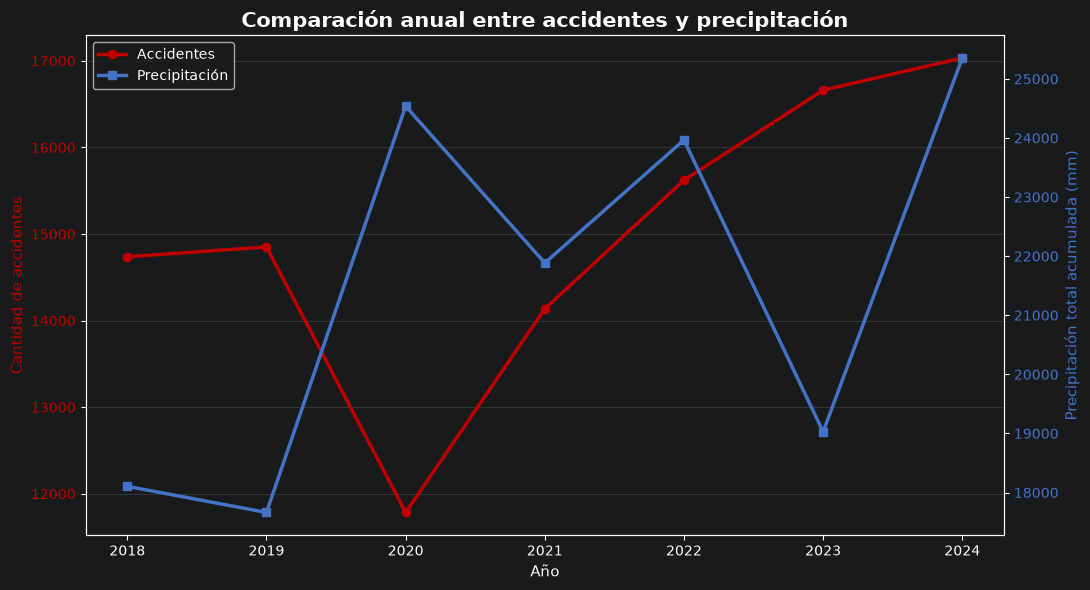

In [21]:
visualizador.grafico_clima_accidentes_anual(tabla_clima_accidentes)
plt.show()


## 6. Primer vistazo al modelado predictivo

Se entrenan aquí los tres algoritmos definidos en `EntrenadorModelos` (Regresión Logística, Árbol de Decisión y KNN) para explorar resultados de forma interactiva. El entrenamiento final para producción se ejecuta desde `main.py`, que además guarda el modelo con `GuardadorModelo`.

In [22]:
preparador_modelo = PreparadorModelo()

datos_modelo = preparador_modelo.relacionar_con_clima(accidentes, clima)

X, y = preparador_modelo.separar_variables(datos_modelo)

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = (
    preparador_modelo.dividir_datos(X, y)
)

preprocesador = preparador_modelo.crear_preprocesador()


Accidentes y clima relacionados correctamente.
Filas despues de la relacion: 104821
Columnas despues de la relacion: 28

Variables separadas correctamente.
Filas de X: 104821
Columnas de X: 21
Filas de y: 104821

Division de datos terminada.
Filas de entrenamiento: 83856
Filas de prueba: 20965

Preprocesador creado correctamente.


In [23]:
entrenador = EntrenadorModelos(preprocesador)

tabla_comparacion = entrenador.entrenar_todos(
    X_entrenamiento, y_entrenamiento, X_prueba, y_prueba
)

tabla_comparacion


Modelos creados correctamente.
- Regresion Logistica
- Arbol de Decision
- KNN

ENTRENANDO: Regresion Logistica
Entrenamiento terminado en 1.12 segundos.

Metricas obtenidas:
Accuracy: 0.7031
Precision de graves: 0.2792
Recall de graves: 0.6554
F1-score de graves: 0.3916
ROC-AUC: 0.7429

Matriz de confusion:
[[12737  5172]
 [ 1053  2003]]

ENTRENANDO: Arbol de Decision
Entrenamiento terminado en 2.30 segundos.

Metricas obtenidas:
Accuracy: 0.6739
Precision de graves: 0.2590
Recall de graves: 0.6649
F1-score de graves: 0.3728
ROC-AUC: 0.7209

Matriz de confusion:
[[12096  5813]
 [ 1024  2032]]

ENTRENANDO: KNN
Entrenamiento terminado en 0.67 segundos.

Metricas obtenidas:
Accuracy: 0.8370
Precision de graves: 0.3466
Recall de graves: 0.1335
F1-score de graves: 0.1928
ROC-AUC: 0.6354

Matriz de confusion:
[[17140   769]
 [ 2648   408]]


,modelo,accuracy,precision,recall,f1_score,roc_auc,tiempo_segundos
0,Arbol de Decision,0.6739,0.2590,0.6649,0.3728,0.7209,2.30
1,Regresion Logistica,0.7031,0.2792,0.6554,0.3916,0.7429,1.12
2,KNN,0.8370,0.3466,0.1335,0.1928,0.6354,0.67


In [24]:
nombre_mejor_modelo, mejor_pipeline = entrenador.seleccionar_mejor_modelo()

display(entrenador.obtener_matriz_confusion(nombre_mejor_modelo))
display(entrenador.obtener_reporte(nombre_mejor_modelo))



MEJOR MODELO
Modelo seleccionado: Arbol de Decision
Recall de accidentes graves: 0.6649
F1-score de accidentes graves: 0.3728
ROC-AUC: 0.7209


array([[12096,  5813],
       [ 1024,  2032]])

,precision,recall,f1-score,support
Leve,0.921951,0.675415,0.779658,17909.000000
Grave,0.259018,0.664921,0.372810,3056.000000
accuracy,0.673885,0.673885,0.673885,0.673885
macro avg,0.590485,0.670168,0.576234,20965.000000
weighted avg,0.825318,0.673885,0.720353,20965.000000


# 7. Conclusiones

En este notebook se puede observar los resultados de cada uno de los pasos realizados por lo cual daremos conclusiones generales sobre cada uno de los pasos abarcados.

### Paso 3: EDA

En el apartado del EDA observamos distintas observaciones muy interesantes, una de estas era que en el 2020 fue el año donde menos accidentes se registraron, eso debido a la situación que estaba viviendo no solo el país sino el mundo con la pandemia del Covid-19, también observamos que Aunque Guanacaste tuviera de las cantidades mas bajas de accidentes registradas con un 37.42% era la que mayor porcentaje tenía en accidentes graves e inclusive con personas fallecidas.


### Paso 4: Visualización
Este paso muestra de una manera visual (gráfica) los resultados que se obtuvieron durante el EDA, por ejemplo observar como el accidente mas común es "colisión_con_motocicleta" con mas de 40 mil registros o en el mapa de calor observamos la diferencia entre el la franja horaria de 12:00 17:59 a comparación de otras franjas en cuanto a cantidad de accidentes.


### Paso 5: Integración de Precipitación
Se integran la precipitación que hubo en ese año a los datos y se realiza una comprobación entre la precipitación y los accidentes del año, observando como en 2020 hubo mucha precipitación y pocos accidentes y en 2023 hubieron muchos accidentes y poca precipitación.


### Paso 6: Creación y Comparativa de Modelos
En este caso se trabajaron un total de 3 modelos siendo:
- Regresión Logística
- Árbol de desición
- KNN

Y mostrando las distintas estadísticas y resultados de cada modelo, observamos como KNN fue el que tuvo mayor exactitud pero también quien generó mas falsos positivos, en cambio recall que es la que nos da cuantos accidentes graves pudo detectar el modelo KNN fue el mas bajo a comparación de los otros dos que tuvieron 0.6 (un 60%), luego tenemos el F1-Score que muestra un balance entre Precision y Recall y por último tenemos Roc Auc la cual esta distingue distintos umbrales entre las clases.

A la hora de comparar las distintas categorías explicadas anteriormente observamos que el mejor modelo es el Árbol de Decisión, ya que aunque los otros modelos les ganaban en ciertas variables, este fue el que tuvo mayor constancia (a pesar de que KNN tuvo mayor precisión este detectó peor los accidentes graves por ejemplo).